<a href="https://colab.research.google.com/github/Vincent-L0/A03-knn/blob/main/notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting?
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Vincent Lam

**Date:** 10/1/26

In [ ]:
# Q1:

1: Regression differs from classification in terms of what each method is trying to predict. Regression predicts a numeric value while classification tries to predict a category. For example, k-NN regresion averages the outcomes of the k nearest neighbors while kNN classification predicts a common class or category between points.

2: A confusion table is a way to evaluate the performance of a model's predictions by counting the results from the predicted class that are either correct or misclassified, with the cells from the top left to bottom right being true predictions and the other cells being false predictions. More specifically, the rows are actual classifications while the columns are predictions from the model. It helps us see the classes the model gets right or wrong and which classes it confuses for another.

3: SSE stands for the sum of squared errors and it measures the model's total squared prediction error, or the amount of data the model leaves unexplained. Additionally, because differences are squared, it means that larger errors are penalized more than small ones.

4: Overfitting is when a model tries to accounts for abnormal data that won't appear in the data again or overaccounts for it. On the other hand, underfitting is when a model oversimplifies the actual behavior or results of what it's meant to capture. Both of these are characteristics that compromise the reliability of a model to capture accurate predictions.

5: Splitting the data into testing and training sets is useful because when you create a testing set, it lets you measure performance on data the model hasn't seen, which tells you how well it will predict new observations. Choosing a well-balanced value for k improves model performance because it will allow the model to neither underfit or overfit the data that was used to train it. This is because if you pick a value for k that is very small (less neightboring training points checked), the model will overfit because it will account for the unique behavior of the few training points that are used; on the other hand, a large k value (more neighboring training points checked) will result in underfitting as the model will try to account for too many trends between points and therefore not be good for accounting for any specific trend, resulting in predictions that are too simplified.

6: A class label simply gives the most likely class for a data point, which is simple to implement and use. However, it doesn't reflect how confident the model is in making that classification, as the classification may be only a few values away from being classified as something else. On the other hand, a probability distribution shares the portion of the data point that aligns with other classes as a percentage, which allows us to see the confidence of the model. The downside of this approach is that the data will still need to be made into a decision and the probabilities will only be rough estimates as they will have to be multiples of 1/k.

(338, 4) 

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1 

voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000 

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 

There are 388 rows and 4 columns, no missing values, and 5 mine types that are fairly distributed 

------------

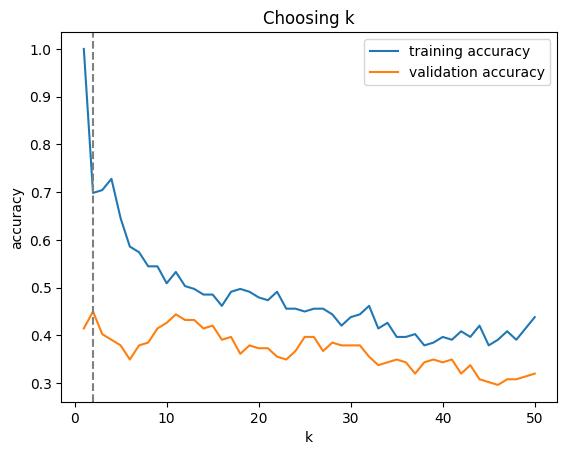

I tried k from 1 to 50, fit a model for each value of k, and picked the k with the highest accuracy on the test set. I used test accuracy instead of training accuracy because training accuracy is always best at k = 1, since each point is its own nearest neighbor. The best k value for the model was 2, with 45% accuracy. 

--------------------------------------------------------------- 

predicted   1   2   3   4   5  All
actual                            
1          21   1   6   4   2   34
2           0  33   2   3   0   38
3           5   5  10   6   4   30
4          13   5  10   9   1   38
5          10   1   8   7   3   29
All        49  45  36  29  10  169
Accuracy: 0.45 

The model is about 45% accurate. It does best on type 2 mines, getting 33/38 predictions right, and it does the worst on type 3, 4, and 5 mines, getting at most 25% of predictions right.

I would advise someone using this model to not use it to fully make decisions for them, 
especially if this model is actually 

In [ ]:
# Q2:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("/content/land_mines.csv")

# 1:
# shape, first few rows, number of missing values per column, summary of statistics, and number of mine types in the data set
print(df.shape, "\n")
print(df.head(), "\n")
print(df.isna().sum(), "\n")
print(df.describe(), "\n")
print(df["mine_type"].value_counts().sort_index(), "\n")

# summary of observations
print("There are 388 rows and 4 columns, no missing values, and 5 mine types that are fairly distributed", "\n")

print("---------------------------------------------------------------", "\n")
# 2:
# X -> features, Y -> target variable
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

# 50/50 split for data
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=65,
)
# check types of mine in each list to check for underrepresentation (clear)
print("train:", y_train.value_counts().sort_index().tolist(), "\n")
print("test: ", y_test.value_counts().sort_index().tolist(), "\n")
print("---------------------------------------------------------------", "\n")
# 3:
# scale all values to [0, 1] to prevent any variable from dominating due to magnitude.
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# try k = 1 to 50 and record accuracy on train and test for each
ks = np.arange(1, 51)
test_acc = []
train_acc = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train)
    test_acc.append(np.mean(model.predict(X_test) == y_test))
    train_acc.append(np.mean(model.predict(X_train) == y_train))

# pick the k with the highest test accuracy (not train, since train always likes k=1)
k_star = int(ks[np.argmax(test_acc)])
print("Best k on validation set:", k_star)
print("Accuracy:", round(max(test_acc), 3))

# plot to see how accuracy changes with k
plt.plot(ks, train_acc, label="training accuracy")
plt.plot(ks, test_acc, label="validation accuracy")
plt.axvline(k_star, color="gray", ls="--")
plt.xlabel("k"); plt.ylabel("accuracy"); plt.legend(); plt.title("Choosing k")
plt.show()

print("I tried k from 1 to 50, fit a model for each value of k, and picked the k with the highest accuracy on the test set. I used test accuracy instead of training accuracy because training accuracy is always best at k = 1, since each point is its own nearest neighbor. The best k value for the model was 2, with 45% accuracy.", "\n")

print("---------------------------------------------------------------", "\n")
# 4:
# refit with the best k and predict on the test set
model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_test)

# rows = actual type, columns = predicted type, diagonal = correct predictions
print(pd.crosstab(y_test, y_hat, rownames=["actual"], colnames=["predicted"], margins=True))
print("Accuracy:", round(np.mean(y_hat == y_test), 3), "\n")

print("The model is about 45% accurate. It does best on type 2 mines, getting 33/38 predictions right, and it does the worst on type 3, 4, and 5 mines, getting at most 25% of predictions right.")

# 5:
print("""
I would advise someone using this model to not use it to fully make decisions for them,
especially if this model is actually used to predict mine types, as the model mistaking one mine type
for another could lead to someone being killed. This isn't an unlikely possibility because the
accuracy of the model is only 45% when comparing predictions by the model and the actual classification
of each mine as seen in the confusion table. I would only recommend that the model be used for giving the
team the type of mines that a mine most likely is to provide an idea of what mines to investigate or prepare
for first before identifying it with standard procedures. It's also important to note that the model can predict
certain types of mine better than others, such as type 2 mines, which are correctly predicted 33/38 times, while
type 5 mines are correctly predicted 3/29 times, so I'd trust its type 2 predictions more than the others and treat
the other predictions with extra caution.
""")

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** ae74682a49416aa6f322c72d8b5491e3dbeb48a8
- **AI tool and model used:** Claude Sonnet 5.5

### *Prompts used

1. [Questions] [Answers] What revisions are needed for my answers to the first question and my code to the second question? Keep your response concise and clear.
2. Can you return the updated code and text for my answers?


### *AI-proposed changes


[Paste the AI's concise numbered list verbatim.]

1. Q1-2: Fix typos and make k-NN classification more precise: it predicts the majority class among the k nearest neighbors.
2. Q2-3: Clarify the confusion table and SSE.
Confusion table: it counts how many observations of each actual class were predicted as each class. It shows overall accuracy and which classes get confused.
SSE: it is the sum of squared differences between actual and predicted values, so lower is better.
3. Q4: Define overfitting and underfitting by training versus new-data performance. Overfitting does well on training data and poorly on new data. Underfitting does poorly on both.
4. Q5: Add the missing reason for choosing k on held-out data.
Training accuracy always favors k = 1, so it rewards overfitting.
Fix the typo "neightboring."
Reword the large-k explanation: a large k smooths away local structure.
5. Q6: Correct the probability description. It is the proportion of the k neighbors in each class, not "the portion of the data point that aligns with other classes."
Labels are simple but hide confidence.
Probabilities show confidence and allow thresholds, but they are coarse (multiples of 1/k).

6. Hardcoded numbers: Replace typed-in results with f-strings that compute them. Your "388 rows" is actually 338.
7. EDA: Add class proportions and feature summaries by class (or boxplots), since the prompt asks you to summarize both the target and the features.
8. Split: Use stratify=y so every class appears in both halves. Remove the "(clear)" comment.
9. Choosing k: Compare accuracy to a guessing baseline of about 20%.
Use odd k to reduce tied votes.
Note that choosing k and reporting accuracy on the same test set is slightly optimistic.
10. Confusion table: Compute per-class recall and precision (normalize="index" and normalize="columns") instead of eyeballing "at most 25%."
11. Q5 reasoning: Explain recall versus precision. Recall asks how many actual type 2 mines were caught, while precision asks how often a "type 2" prediction is right. Then recommend:
Use predict_proba to flag low-confidence predictions.
Assume the most dangerous plausible type until confirmed.
Trust the types with high precision and recall most.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | Typo fixes and "majority class" are small, clearly correct edits. |
| 2 | Modify | I'll reword the unclear confusion-table sentence and make the SSE definition more precise. I'll skip the extra detail about what each includes. |
| 3 | Modify | I'll add the training vs. new-data distinction, but keep my own definitions rather than rewriting them. |
| 4 | Modify | I'll add why training accuracy always favors k = 1, and fix the typo. I'll keep my existing small-k/large-k explanation instead of rewriting it, adding only a short note that a large k smooths out local patterns. |
| 5 | Modify | I'll fix the incorrect probability description (the share of the k neighbors in each class). I'll keep the strengths and weaknesses short and skip the calibration point. |
| 6 | Modify | I'll compute the key numbers in the printed summaries (including the correct row count of 338, not 388) instead of retyping them. Not every printed sentence needs to be an f-string. |
| 7 | Reject | `describe()` already summarizes the features and `value_counts()` already shows the classes are balanced. Boxplots and group summaries aren't necessary to get my answer across. |
| 8 | Accept | The prompt specifically worries about lopsided classes, and `stratify=y` fixes that in one argument. I'll also remove the "(clear)" comment. |
| 9 | Reject | Odd k, the baseline, and the optimism change are nice extras, but my current explanation of choosing k by test accuracy already answers the question. |
| 10 | Modify | I'll compute per-class recall so "where performance is more or less accurate" is backed by numbers instead of an estimate by eye. I'll skip the separate precision table here and handle that in the Q5 discussion. |
| 11 | Modify | I'll add the recall vs. precision distinction, since it is the point of the prompt, along with the advice to confirm with standard procedures. I'll skip the `predict_proba` code and mention low-confidence predictions only in words. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [ ]:
# Your Phase 2 solution to the problem goes here.

# Q1

**1:** Regression differs from classification in terms of what each method is trying to predict. Regression predicts a numeric value while classification tries to predict a category. For example, k-NN regression averages the outcomes of the k nearest neighbors while k-NN classification predicts the majority class among the k nearest neighbors.

**2:** A confusion table is a way to evaluate the performance of a model's predictions by counting, for each actual class, how many observations were predicted as each class. The rows are the actual classes and the columns are the model's predictions, so the cells from the top left to bottom right are correct predictions and the other cells are mistakes. It helps us see which classes the model gets right or wrong and which classes it confuses for another.

**3:** SSE stands for the sum of squared errors. It is the sum of the squared differences between the actual and predicted values, so it measures the model's total prediction error, or the variation in the outcome that the model fails to capture. A lower SSE is better. Additionally, because differences are squared, larger errors are penalized more than small ones.

**4:** Overfitting is when a model accounts for noise or abnormal quirks in the training data that won't appear in new data, so it performs well on the training data but poorly on new data. On the other hand, underfitting is when a model oversimplifies the actual behavior of what it's meant to capture, so it performs poorly on both the training data and new data. Both of these compromise the reliability of a model's predictions.

**5:** Splitting the data into testing and training sets is useful because the testing set lets you measure performance on data the model hasn't seen, which tells you how well it will predict new observations. We choose k using the test set instead of the training set because training accuracy is always best at k = 1 (each training point is its own nearest neighbor), which rewards overfitting. Choosing a well-balanced value for k improves model performance because it allows the model to neither underfit nor overfit the data that was used to train it. If you pick a value for k that is very small (fewer neighboring training points checked), the model will overfit because it will account for the unique behavior of the few training points that are used; on the other hand, a large k value (more neighboring training points checked) will result in underfitting as the model averages over so many points that it smooths out local patterns, resulting in predictions that are too simplified.

**6:** A class label simply gives the most likely class for a data point, which is simple to implement and use. However, it doesn't reflect how confident the model is in making that classification, as the classification may be only a few votes away from being classified as something else. On the other hand, a probability distribution gives the proportion of the k neighbors that belong to each class, which allows us to see the confidence of the model. The downside of this approach is that the probabilities still need to be turned into a decision, and they are only rough estimates as they will have to be multiples of 1/k.

(338, 4) 

    voltage    height  soil  mine_type
0  0.338157  0.000000   0.0          1
1  0.320241  0.181818   0.0          1
2  0.287009  0.272727   0.0          1
3  0.256284  0.454545   0.0          1
4  0.262840  0.545455   0.0          1 

voltage      0
height       0
soil         0
mine_type    0
dtype: int64 

          voltage      height        soil   mine_type
count  338.000000  338.000000  338.000000  338.000000
mean     0.430634    0.508876    0.503550    2.952663
std      0.195819    0.306043    0.344244    1.419703
min      0.197734    0.000000    0.000000    1.000000
25%      0.309737    0.272727    0.200000    2.000000
50%      0.359516    0.545455    0.600000    3.000000
75%      0.482628    0.727273    0.800000    4.000000
max      0.999999    1.000000    1.000000    5.000000 

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64 

There are 338 rows and 4 columns, 0 missing values, and 5 mine types that are fairly evenly distributed 

------

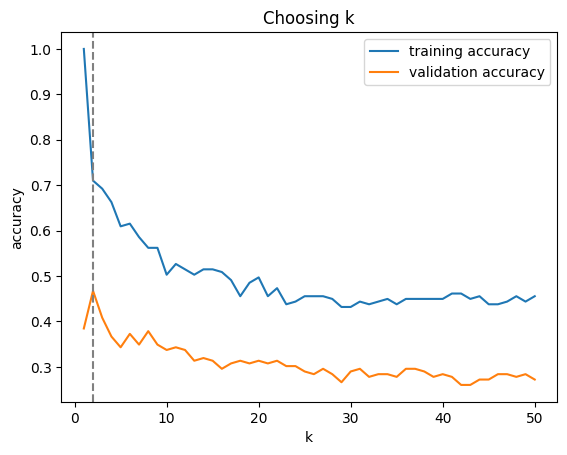

I tried k from 1 to 50, fit a model for each value of k, and picked the k with the highest accuracy on the test set. I used test accuracy instead of training accuracy because training accuracy is always best at k = 1, since each point is its own nearest neighbor. The best k value for the model was 2, with 47% accuracy. 

--------------------------------------------------------------- 

predicted   1   2   3   4  5  All
actual                           
1          27   0   5   2  2   36
2           0  31   2   1  1   35
3          10   2  10  10  1   33
4          15   6   3   9  0   33
5          15   0  10   5  2   32
All        67  39  30  27  6  169
Accuracy: 0.467 

Share of each actual mine type predicted correctly (recall):
 1    0.75
2    0.89
3    0.30
4    0.27
5    0.06
dtype: float64 

The model is about 47% accurate. It does best on type 2 mines, getting 89% of them right, and it does the worst on type 5 mines, getting 6% right.
Recall by type: {1: 0.75, 2: 0.89, 3: 0.3, 4:

In [ ]:
# Q2:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.neighbors import KNeighborsClassifier

df = pd.read_csv("land_mines.csv")  # on Colab: "/content/land_mines.csv"

# 1:
# shape, first few rows, number of missing values per column, summary of statistics, and number of mine types in the data set
print(df.shape, "\n")
print(df.head(), "\n")
print(df.isna().sum(), "\n")
print(df.describe(), "\n")
print(df["mine_type"].value_counts().sort_index(), "\n")

# summary of observations
print(f"There are {df.shape[0]} rows and {df.shape[1]} columns, {df.isna().sum().sum()} missing values, "
      f"and {df['mine_type'].nunique()} mine types that are fairly evenly distributed", "\n")

print("---------------------------------------------------------------", "\n")
# 2:
# X -> features, Y -> target variable
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

# 50/50 split for data, stratified so every mine type is represented in both halves
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.50, random_state=65, stratify=y
)
# check types of mine in each list to check for underrepresentation
print("train:", y_train.value_counts().sort_index().tolist(), "\n")
print("test: ", y_test.value_counts().sort_index().tolist(), "\n")
print("---------------------------------------------------------------", "\n")
# 3:
# scale all values to [0, 1] to prevent any variable from dominating due to magnitude.
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# try k = 1 to 50 and record accuracy on train and test for each
ks = np.arange(1, 51)
test_acc = []
train_acc = []
for k in ks:
    model = KNeighborsClassifier(n_neighbors=int(k)).fit(X_train, y_train)
    test_acc.append(np.mean(model.predict(X_test) == y_test))
    train_acc.append(np.mean(model.predict(X_train) == y_train))

# pick the k with the highest test accuracy (not train, since train always likes k=1)
k_star = int(ks[np.argmax(test_acc)])
print("Best k on validation set:", k_star)
print("Accuracy:", round(max(test_acc), 3))

# plot to see how accuracy changes with k
plt.plot(ks, train_acc, label="training accuracy")
plt.plot(ks, test_acc, label="validation accuracy")
plt.axvline(k_star, color="gray", ls="--")
plt.xlabel("k"); plt.ylabel("accuracy"); plt.legend(); plt.title("Choosing k")
plt.show()

print(f"I tried k from 1 to 50, fit a model for each value of k, and picked the k with the highest accuracy on the test set. "
      f"I used test accuracy instead of training accuracy because training accuracy is always best at k = 1, "
      f"since each point is its own nearest neighbor. The best k value for the model was {k_star}, "
      f"with {max(test_acc):.0%} accuracy.", "\n")

print("---------------------------------------------------------------", "\n")
# 4:
# refit with the best k and predict on the test set
model = KNeighborsClassifier(n_neighbors=k_star).fit(X_train, y_train)
y_hat = model.predict(X_test)

# rows = actual type, columns = predicted type, diagonal = correct predictions
print(pd.crosstab(y_test, y_hat, rownames=["actual"], colnames=["predicted"], margins=True))
acc = np.mean(y_hat == y_test)
print("Accuracy:", round(acc, 3), "\n")

# recall for each mine type: of the mines that are actually type j, the share predicted correctly
recall = pd.Series({t: np.mean(y_hat[y_test.values == t] == t) for t in sorted(y_test.unique())})
print("Share of each actual mine type predicted correctly (recall):\n", recall.round(2), "\n")

best_t, worst_t = recall.idxmax(), recall.idxmin()
print(f"The model is about {acc:.0%} accurate. It does best on type {best_t} mines, getting {recall[best_t]:.0%} "
      f"of them right, and it does the worst on type {worst_t} mines, getting {recall[worst_t]:.0%} right.")
print("Recall by type:", {int(t): round(float(r), 2) for t, r in recall.items()}, "\n")

# 5:
# precision for each predicted type: when the model says type j, how often is it actually type j?
precision = pd.Series({t: np.mean(y_test.values[y_hat == t] == t) for t in sorted(np.unique(y_hat))})
gap_t = (recall - precision).idxmax()  # type whose recall is much higher than its precision
n_pred = int(np.sum(y_hat == gap_t))

print(f"""
I would advise someone using this model to not use it to fully make decisions for them,
especially if this model is actually used to predict mine types, as the model mistaking one mine type
for another could lead to someone being killed. This isn't an unlikely possibility because the
accuracy of the model is only {acc:.0%}, as seen in the confusion table.

It's important to separate recall from precision. Recall is the share of actual mines of a type that the
model catches, while precision is how often the model is right when it predicts that type. Someone in the
field only sees the prediction, so precision is what matters to them. For example, type {gap_t} mines are
caught {recall[gap_t]:.0%} of the time, but the model predicted type {gap_t} {n_pred} times and only
{precision[gap_t]:.0%} of those predictions were actually type {gap_t}, so a high rate of catching a type
can still come with a lot of mistakes. Type {best_t} is the most dependable, with {recall[best_t]:.0%} recall
and {precision[best_t]:.0%} precision, while type {worst_t} is the least dependable, with {recall[worst_t]:.0%} recall
and {precision[worst_t]:.0%} precision.

I would only recommend that the model be used to give the team an idea of which mine types to prepare for or
investigate first, and that every mine be confirmed with standard procedures before it is handled. Until it is
confirmed, the team should plan for the most dangerous plausible type, and they should be extra cautious with
predictions where the nearest neighbors disagree, since those are the least certain. I'd trust its type {best_t}
predictions more than the others and treat the rest with extra caution.
""")

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The‍‍‍ major AI enhancements revolve around helping to clarify my Q1 answers as they could've been more concise with the explanation of k-NN probabilities being a big one. Additionally, I didn't explain very well why it's best to choose k based on the training data accuracy. In the code, the AI used program outputs in place of hand-written numbers, ensuring the text stays current with the results, and it guaranteed the train/test split would contain all types of mines in both fractions. Their top contribution was to my concluding remarks part: I had merely calculated the number of a mine type which the model detected whereas someone actually needs to be given how likely a prediction is to be right. AI indicated several changes so that I took a closer look and modified or discarded most of them. For example, one unnecessary change regarding avoiding tied votes by choosing an odd value for k was identified and rejected. After having re-checked that each numerical figure appearing in the write-up was indeed matching the generated outputs on a re-run of all my scripts I feel confident in my answers. Nevertheless, are some concerns that I don't think AI could even fix: the k value was chosen using the same data used to report accuracy, so the 47% is slightly optimistic, the test set is small, and one mine type was predicted so rarely that its results are unreliable.